In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedShuffleSplit

from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

from sklearn.model_selection  import StratifiedShuffleSplit

from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.compose import ColumnTransformer
from predict_function import predict

from sklearn.base import BaseEstimator, TransformerMixin


class Add_features(BaseEstimator, TransformerMixin):

    def __init__(self):
        self.lon = 0
        self.lat = 1
        self.hma = 2
        self.trms = 3
        self.pop = 5
        self.med_inc = 7

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        lat_long = X[:, self.lon] + X[:, self.lat]
        hma_med_inc = X[:, self.hma] / X[:, self.med_inc]
        trms_pop = X[:, self.trms] / X[:, self.pop]

        return np.c_[X, lat_long, hma_med_inc, trms_pop]
        


house = pd.read_csv('D:\\Internship\\ds-aiml-genai-internship\\Data\\Housing.csv')

X = house.drop('median_house_value', axis=1).copy()
y = house.median_house_value


split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=123)
(train_idx, test_idx), = split.split(X, X['ocean_proximity'])

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]


num_features = X.select_dtypes('float').columns
cat_features = X.select_dtypes('object').columns


num_pipline = Pipeline([
    ('impute', SimpleImputer()),
    ('add_feature', Add_features()),
    ('scale', StandardScaler())
])

cat_pipeline = Pipeline([
    ('one_hot_encoder', OneHotEncoder(sparse_output=False))
])


final_pipeline = ColumnTransformer([
    ('num_pipeline', num_pipline, num_features),
    ('cat_pipeline', cat_pipeline, cat_features)
])

final_pipeline.fit(X_train)

X_train_tr = final_pipeline.transform(X_train)
X_test_tr = final_pipeline.transform(X_test)



models = [
    ('Random_forest', RandomForestRegressor(n_jobs=-1)),
    ('sgd', SGDRegressor()),
    ('SVM', SVR()),
    ('k neighbors', KNeighborsRegressor())
]

predict(models, X_train_tr, X_test_tr, y_train, y_test)

Model: Random_forest
R2 Score: 0.8290
MAE: 29899.89

Model: sgd
R2 Score: 0.6449
MAE: 49267.27

Model: SVM
R2 Score: -0.0448
MAE: 86533.17

Model: k neighbors
R2 Score: 0.7429
MAE: 38091.46



In [2]:
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.linear_model import SGDRegressor
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.base import BaseEstimator, TransformerMixin

from predict_function import predict


class Add_features(BaseEstimator, TransformerMixin):

    def __init__(self):
        self.lon = 0
        self.lat = 1
        self.hma = 2
        self.trms = 3
        self.pop = 5
        self.med_inc = 7

    def fit(self, X, y=None):
        return self

    def transform(self, X):

        lat_long = X[:, self.lon] + X[:, self.lat]

        hma_med_inc = (
            X[:, self.hma] /
            X[:, self.med_inc]
        )

        trms_pop = (
            X[:, self.trms] /
            X[:, self.pop]
        )

        return np.c_[
            X,
            lat_long,
            hma_med_inc,
            trms_pop
        ]


# Load dataset
house = pd.read_csv(
    r'D:\Internship\ds-aiml-genai-internship\Data\Housing.csv'
)


# X and y
X = house.drop(
    'median_house_value',
    axis=1
).copy()

y = house['median_house_value']


# Stratified split
split = StratifiedShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=123
)

(train_idx, test_idx), = split.split(
    X,
    X['ocean_proximity']
)


X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]


# Features
num_features = [
    'longitude',
    'latitude',
    'housing_median_age',
    'total_rooms',
    'total_bedrooms',
    'population',
    'households',
    'median_income'
]

cat_features = [
    'ocean_proximity'
]


# Numerical pipeline
num_pipeline = Pipeline([
    ('impute', SimpleImputer()),
    ('add_feature', Add_features()),
    ('scale', StandardScaler())
])


# Categorical pipeline
cat_pipeline = Pipeline([
    (
        'one_hot_encoder',
        OneHotEncoder(
            sparse_output=False,
            handle_unknown='ignore'
        )
    )
])


# Final pipeline
final_pipeline = ColumnTransformer([
    (
        'num_pipeline',
        num_pipeline,
        num_features
    ),
    (
        'cat_pipeline',
        cat_pipeline,
        cat_features
    )
])


# Fit pipeline
final_pipeline.fit(X_train)


# Transform data
X_train_tr = final_pipeline.transform(X_train)
X_test_tr = final_pipeline.transform(X_test)


# Models
models = [
    (
        'Random Forest',
        RandomForestRegressor(
            n_jobs=-1,
            random_state=123
        )
    ),

    (
        'SGD',
        SGDRegressor(
            random_state=123
        )
    ),

    (
        'SVM',
        SVR()
    ),

    (
        'K Neighbors',
        KNeighborsRegressor()
    )
]


# Train and evaluate
predict(
    models,
    X_train_tr,
    X_test_tr,
    y_train,
    y_test
)

Model: Random Forest
R2 Score: 0.8285
MAE: 29895.98

Model: SGD
R2 Score: 0.6439
MAE: 49203.95

Model: SVM
R2 Score: -0.0448
MAE: 86533.17

Model: K Neighbors
R2 Score: 0.7429
MAE: 38091.46



In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedShuffleSplit

from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

from sklearn.model_selection  import StratifiedShuffleSplit

from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.compose import ColumnTransformer
from predict_function import predict

from sklearn.base import BaseEstimator, TransformerMixin


class Add_features(BaseEstimator, TransformerMixin):

    def __init__(self):
        self.lon = 0
        self.lat = 1
        self.hma = 2
        self.trms = 3
        self.pop = 5
        self.med_inc = 7

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        lat_long = X[:, self.lon] + X[:, self.lat]
        hma_med_inc = X[:, self.hma] / X[:, self.med_inc]
        trms_pop = X[:, self.trms] / X[:, self.pop]

        return np.c_[X, lat_long, hma_med_inc, trms_pop]
        


house = pd.read_csv('D:\\Internship\\ds-aiml-genai-internship\\Data\\Housing.csv')

X = house.drop('median_house_value', axis=1).copy()
y = house.median_house_value


split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=123)
(train_idx, test_idx), = split.split(X, X['ocean_proximity'])

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]


num_features = X.select_dtypes('float').columns
cat_features = X.select_dtypes('object').columns


num_pipline = Pipeline([
    ('impute', SimpleImputer()),
    ('add_feature', Add_features()),
    ('scale', StandardScaler())
])

cat_pipeline = Pipeline([
    ('one_hot_encoder', OneHotEncoder(sparse_output=False))
])


final_pipeline = ColumnTransformer([
    ('num_pipeline', num_pipline, num_features),
    ('cat_pipeline', cat_pipeline, cat_features)
])

final_pipeline.fit(X_train)

X_train_tr = final_pipeline.transform(X_train)
X_test_tr = final_pipeline.transform(X_test)



models = [
    ('Random_forest', RandomForestRegressor(n_estimators=500, max_depth=10, n_jobs=-1)),
    ('sgd', SGDRegressor(max_iter=2000)),
    ('SVM', SVR(kernel='linear')),
    ('k neighbors', KNeighborsRegressor(n_neighbors=50))
]

predict(models, X_train_tr, X_test_tr, y_train, y_test)

Model: Random_forest
R2 Score: 0.8053
MAE: 33165.72

Model: sgd
R2 Score: 0.6420
MAE: 49511.13

Model: SVM
R2 Score: 0.1426
MAE: 76521.33

Model: k neighbors
R2 Score: 0.7371
MAE: 40018.99



In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedShuffleSplit

from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

from sklearn.model_selection  import StratifiedShuffleSplit

from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.compose import ColumnTransformer
from predict_function import predict

from sklearn.base import BaseEstimator, TransformerMixin


class Add_features(BaseEstimator, TransformerMixin):

    def __init__(self):
        self.lon = 0
        self.lat = 1
        self.hma = 2
        self.trms = 3
        self.pop = 5
        self.med_inc = 7

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        lat_long = X[:, self.lon] + X[:, self.lat]
        hma_med_inc = X[:, self.hma] / X[:, self.med_inc]
        trms_pop = X[:, self.trms] / X[:, self.pop]

        return np.c_[X, lat_long, hma_med_inc, trms_pop]
        


house = pd.read_csv('D:\\Internship\\ds-aiml-genai-internship\\Data\\Housing.csv')

X = house.drop('median_house_value', axis=1).copy()
y = house.median_house_value


split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=123)
(train_idx, test_idx), = split.split(X, X['ocean_proximity'])

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]


num_features = X.select_dtypes('float').columns
cat_features = X.select_dtypes('object').columns


num_pipline = Pipeline([
    ('impute', SimpleImputer()),
    ('add_feature', Add_features()),
    ('scale', StandardScaler())
])

cat_pipeline = Pipeline([
    ('one_hot_encoder', OneHotEncoder(sparse_output=False))
])


final_pipeline = ColumnTransformer([
    ('num_pipeline', num_pipline, num_features),
    ('cat_pipeline', cat_pipeline, cat_features)
])

final_pipeline.fit(X_train)

X_train_tr = final_pipeline.transform(X_train)
X_test_tr = final_pipeline.transform(X_test)



In [6]:

models = [
    ('Random_forest', RandomForestRegressor(n_estimators=10, max_depth=2, n_jobs=-1))
]

predict(models, X_train_tr, X_test_tr, y_train, y_test)

Model: Random_forest
R2 Score: 0.5060
MAE: 59649.97



In [7]:

models = [
    ('Random_forest', RandomForestRegressor(n_estimators=30, max_depth=3, n_jobs=-1))
]

predict(models, X_train_tr, X_test_tr, y_train, y_test)


Model: Random_forest
R2 Score: 0.6092
MAE: 51844.69



In [8]:
from sklearn.model_selection import GridSearchCV

In [9]:
param_grid = [
    {
        'n_estimators':[50, 100, 150, 200, 250, 300, 350],
        'max_depth':[2, 4, 6, 8, 10],
        'max_features':[1, 3, 5, 6]
    }
]

In [10]:
forest = RandomForestRegressor(n_jobs=-1)

In [11]:
grid_search = GridSearchCV(forest, param_grid, cv=5, scoring='r2',  return_train_score=True)
grid_search

,estimator,RandomForestR...sor(n_jobs=-1)
,param_grid,"[{'max_depth': [2, 4, ...], 'max_features': [1, 3, ...], 'n_estimators': [50, 100, ...]}]"
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_estimators,100


In [12]:
grid_search.fit(X_train_tr, y_train)

,estimator,RandomForestR...sor(n_jobs=-1)
,param_grid,"[{'max_depth': [2, 4, ...], 'max_features': [1, 3, ...], 'n_estimators': [50, 100, ...]}]"
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_estimators,350


In [13]:
grid_search.best_estimator_

,n_estimators,350
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,6
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [14]:
grid_search.best_params_

{'max_depth': 10, 'max_features': 6, 'n_estimators': 350}

In [15]:
grid_search.cv_results_

{'mean_fit_time': array([0.1226501 , 0.21089439, 0.3256846 , 0.41116729, 0.50196457,
        0.7030602 , 0.76946907, 0.13223748, 0.30234346, 0.47542419,
        0.67872734, 0.6452486 , 0.76720133, 0.78765311, 0.14213495,
        0.25142131, 0.38433743, 0.54637299, 0.66056256, 0.77077031,
        0.83179755, 0.13815703, 0.25734534, 0.38363285, 0.52933331,
        0.71093431, 0.7559154 , 0.95500951, 0.14577937, 0.27957258,
        0.36210747, 0.47660398, 0.58805923, 0.70963969, 0.82771206,
        0.15473838, 0.30573606, 0.39901638, 0.52474613, 0.6679255 ,
        0.75681243, 0.97383327, 0.2035171 , 0.3915822 , 0.5783474 ,
        0.73849401, 0.76226459, 0.92707105, 1.04392128, 0.18476105,
        0.33725839, 0.49754262, 0.66511269, 0.81942682, 0.96088052,
        1.11788774, 0.13400536, 0.24620066, 0.36753182, 0.4722599 ,
        0.62427335, 0.736026  , 0.83551197, 0.16131458, 0.30909338,
        0.44272752, 0.57568932, 0.71510086, 0.93635011, 1.10772624,
        0.25809021, 0.43695021,

In [16]:
grid_search.cv_results_.keys()

dict_keys(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'param_max_depth', 'param_max_features', 'param_n_estimators', 'params', 'split0_test_score', 'split1_test_score', 'split2_test_score', 'split3_test_score', 'split4_test_score', 'mean_test_score', 'std_test_score', 'rank_test_score', 'split0_train_score', 'split1_train_score', 'split2_train_score', 'split3_train_score', 'split4_train_score', 'mean_train_score', 'std_train_score'])

In [17]:
results = grid_search.cv_results_


In [18]:
results['mean_fit_time']

array([0.1226501 , 0.21089439, 0.3256846 , 0.41116729, 0.50196457,
       0.7030602 , 0.76946907, 0.13223748, 0.30234346, 0.47542419,
       0.67872734, 0.6452486 , 0.76720133, 0.78765311, 0.14213495,
       0.25142131, 0.38433743, 0.54637299, 0.66056256, 0.77077031,
       0.83179755, 0.13815703, 0.25734534, 0.38363285, 0.52933331,
       0.71093431, 0.7559154 , 0.95500951, 0.14577937, 0.27957258,
       0.36210747, 0.47660398, 0.58805923, 0.70963969, 0.82771206,
       0.15473838, 0.30573606, 0.39901638, 0.52474613, 0.6679255 ,
       0.75681243, 0.97383327, 0.2035171 , 0.3915822 , 0.5783474 ,
       0.73849401, 0.76226459, 0.92707105, 1.04392128, 0.18476105,
       0.33725839, 0.49754262, 0.66511269, 0.81942682, 0.96088052,
       1.11788774, 0.13400536, 0.24620066, 0.36753182, 0.4722599 ,
       0.62427335, 0.736026  , 0.83551197, 0.16131458, 0.30909338,
       0.44272752, 0.57568932, 0.71510086, 0.93635011, 1.10772624,
       0.25809021, 0.43695021, 0.65343366, 0.85546002, 1.24209

In [19]:
len(results['mean_fit_time'])

140

In [20]:
mean_train_score = np.round(results['mean_train_score'], 2)
mean_train_score

array([0.29, 0.28, 0.28, 0.29, 0.29, 0.28, 0.29, 0.47, 0.47, 0.48, 0.48,
       0.47, 0.47, 0.47, 0.54, 0.53, 0.54, 0.54, 0.54, 0.54, 0.54, 0.56,
       0.55, 0.55, 0.55, 0.55, 0.55, 0.55, 0.49, 0.5 , 0.49, 0.49, 0.49,
       0.48, 0.49, 0.65, 0.65, 0.65, 0.65, 0.65, 0.65, 0.65, 0.68, 0.68,
       0.68, 0.68, 0.68, 0.68, 0.68, 0.69, 0.69, 0.69, 0.69, 0.69, 0.69,
       0.69, 0.63, 0.63, 0.63, 0.63, 0.63, 0.63, 0.62, 0.74, 0.74, 0.74,
       0.74, 0.74, 0.74, 0.74, 0.76, 0.76, 0.76, 0.76, 0.76, 0.76, 0.76,
       0.77, 0.76, 0.77, 0.76, 0.77, 0.77, 0.77, 0.72, 0.72, 0.72, 0.73,
       0.73, 0.73, 0.73, 0.81, 0.81, 0.81, 0.81, 0.81, 0.81, 0.81, 0.83,
       0.83, 0.83, 0.83, 0.83, 0.83, 0.83, 0.83, 0.83, 0.83, 0.83, 0.83,
       0.83, 0.83, 0.8 , 0.81, 0.8 , 0.81, 0.81, 0.81, 0.81, 0.86, 0.87,
       0.86, 0.87, 0.86, 0.87, 0.87, 0.88, 0.88, 0.88, 0.88, 0.88, 0.88,
       0.88, 0.88, 0.88, 0.88, 0.88, 0.88, 0.88, 0.88])

In [21]:
mean_test_score = np.round(results['mean_test_score'], 2)
mean_test_score

array([0.29, 0.28, 0.28, 0.29, 0.29, 0.28, 0.29, 0.46, 0.47, 0.48, 0.47,
       0.47, 0.47, 0.47, 0.53, 0.53, 0.54, 0.53, 0.54, 0.54, 0.53, 0.55,
       0.55, 0.55, 0.55, 0.55, 0.55, 0.55, 0.48, 0.49, 0.49, 0.48, 0.48,
       0.48, 0.48, 0.64, 0.64, 0.64, 0.64, 0.64, 0.64, 0.64, 0.67, 0.67,
       0.68, 0.68, 0.68, 0.68, 0.68, 0.68, 0.68, 0.68, 0.68, 0.68, 0.68,
       0.68, 0.61, 0.61, 0.61, 0.61, 0.61, 0.61, 0.61, 0.72, 0.72, 0.72,
       0.72, 0.72, 0.72, 0.72, 0.74, 0.74, 0.74, 0.74, 0.74, 0.74, 0.74,
       0.75, 0.75, 0.75, 0.74, 0.75, 0.75, 0.75, 0.69, 0.69, 0.69, 0.69,
       0.69, 0.69, 0.69, 0.77, 0.77, 0.77, 0.77, 0.77, 0.77, 0.77, 0.79,
       0.79, 0.79, 0.79, 0.79, 0.79, 0.79, 0.79, 0.79, 0.79, 0.79, 0.79,
       0.79, 0.79, 0.74, 0.74, 0.74, 0.74, 0.74, 0.74, 0.74, 0.8 , 0.8 ,
       0.8 , 0.8 , 0.8 , 0.8 , 0.8 , 0.81, 0.81, 0.81, 0.81, 0.81, 0.81,
       0.81, 0.81, 0.81, 0.82, 0.81, 0.81, 0.81, 0.82])

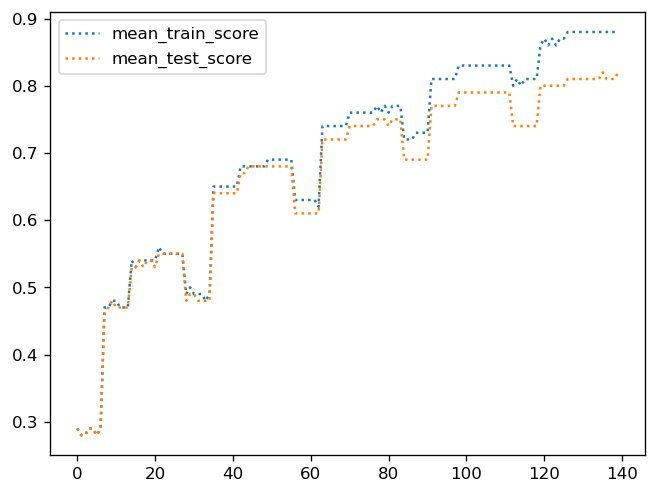

In [22]:
plt.figure(dpi=120)
plt.plot(mean_train_score, ':', label='mean_train_score')
plt.plot(mean_test_score, ':', label='mean_test_score')
plt.legend()
plt.show()

In [23]:
grid_search.best_params_

{'max_depth': 10, 'max_features': 6, 'n_estimators': 350}

In [24]:
results['params']

[{'max_depth': 2, 'max_features': 1, 'n_estimators': 50},
 {'max_depth': 2, 'max_features': 1, 'n_estimators': 100},
 {'max_depth': 2, 'max_features': 1, 'n_estimators': 150},
 {'max_depth': 2, 'max_features': 1, 'n_estimators': 200},
 {'max_depth': 2, 'max_features': 1, 'n_estimators': 250},
 {'max_depth': 2, 'max_features': 1, 'n_estimators': 300},
 {'max_depth': 2, 'max_features': 1, 'n_estimators': 350},
 {'max_depth': 2, 'max_features': 3, 'n_estimators': 50},
 {'max_depth': 2, 'max_features': 3, 'n_estimators': 100},
 {'max_depth': 2, 'max_features': 3, 'n_estimators': 150},
 {'max_depth': 2, 'max_features': 3, 'n_estimators': 200},
 {'max_depth': 2, 'max_features': 3, 'n_estimators': 250},
 {'max_depth': 2, 'max_features': 3, 'n_estimators': 300},
 {'max_depth': 2, 'max_features': 3, 'n_estimators': 350},
 {'max_depth': 2, 'max_features': 5, 'n_estimators': 50},
 {'max_depth': 2, 'max_features': 5, 'n_estimators': 100},
 {'max_depth': 2, 'max_features': 5, 'n_estimators': 150},


In [25]:
for i in range(len(mean_test_score)):
    print(f"{mean_train_score[i]}  {mean_test_score[i]}  {results['params'][i]}")
    print()

0.29  0.29  {'max_depth': 2, 'max_features': 1, 'n_estimators': 50}

0.28  0.28  {'max_depth': 2, 'max_features': 1, 'n_estimators': 100}

0.28  0.28  {'max_depth': 2, 'max_features': 1, 'n_estimators': 150}

0.29  0.29  {'max_depth': 2, 'max_features': 1, 'n_estimators': 200}

0.29  0.29  {'max_depth': 2, 'max_features': 1, 'n_estimators': 250}

0.28  0.28  {'max_depth': 2, 'max_features': 1, 'n_estimators': 300}

0.29  0.29  {'max_depth': 2, 'max_features': 1, 'n_estimators': 350}

0.47  0.46  {'max_depth': 2, 'max_features': 3, 'n_estimators': 50}

0.47  0.47  {'max_depth': 2, 'max_features': 3, 'n_estimators': 100}

0.48  0.48  {'max_depth': 2, 'max_features': 3, 'n_estimators': 150}

0.48  0.47  {'max_depth': 2, 'max_features': 3, 'n_estimators': 200}

0.47  0.47  {'max_depth': 2, 'max_features': 3, 'n_estimators': 250}

0.47  0.47  {'max_depth': 2, 'max_features': 3, 'n_estimators': 300}

0.47  0.47  {'max_depth': 2, 'max_features': 3, 'n_estimators': 350}

0.54  0.53  {'max_dept

In [ ]:
import pickle # 

In [27]:
with open('grid_search.pkl', 'wb') as f:
    pickle.dump(grid_search, f)

In [28]:
grid_search.best_estimator_

,n_estimators,350
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,6
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [29]:
grid_search.best_params_

{'max_depth': 10, 'max_features': 6, 'n_estimators': 350}

In [30]:
grid_search.cv

5

In [31]:
grid_search.cv_results_

{'mean_fit_time': array([0.1226501 , 0.21089439, 0.3256846 , 0.41116729, 0.50196457,
        0.7030602 , 0.76946907, 0.13223748, 0.30234346, 0.47542419,
        0.67872734, 0.6452486 , 0.76720133, 0.78765311, 0.14213495,
        0.25142131, 0.38433743, 0.54637299, 0.66056256, 0.77077031,
        0.83179755, 0.13815703, 0.25734534, 0.38363285, 0.52933331,
        0.71093431, 0.7559154 , 0.95500951, 0.14577937, 0.27957258,
        0.36210747, 0.47660398, 0.58805923, 0.70963969, 0.82771206,
        0.15473838, 0.30573606, 0.39901638, 0.52474613, 0.6679255 ,
        0.75681243, 0.97383327, 0.2035171 , 0.3915822 , 0.5783474 ,
        0.73849401, 0.76226459, 0.92707105, 1.04392128, 0.18476105,
        0.33725839, 0.49754262, 0.66511269, 0.81942682, 0.96088052,
        1.11788774, 0.13400536, 0.24620066, 0.36753182, 0.4722599 ,
        0.62427335, 0.736026  , 0.83551197, 0.16131458, 0.30909338,
        0.44272752, 0.57568932, 0.71510086, 0.93635011, 1.10772624,
        0.25809021, 0.43695021,

In [32]:
7 * 5 * 4

140

In [33]:
results = grid_search.cv_results_
results

{'mean_fit_time': array([0.1226501 , 0.21089439, 0.3256846 , 0.41116729, 0.50196457,
        0.7030602 , 0.76946907, 0.13223748, 0.30234346, 0.47542419,
        0.67872734, 0.6452486 , 0.76720133, 0.78765311, 0.14213495,
        0.25142131, 0.38433743, 0.54637299, 0.66056256, 0.77077031,
        0.83179755, 0.13815703, 0.25734534, 0.38363285, 0.52933331,
        0.71093431, 0.7559154 , 0.95500951, 0.14577937, 0.27957258,
        0.36210747, 0.47660398, 0.58805923, 0.70963969, 0.82771206,
        0.15473838, 0.30573606, 0.39901638, 0.52474613, 0.6679255 ,
        0.75681243, 0.97383327, 0.2035171 , 0.3915822 , 0.5783474 ,
        0.73849401, 0.76226459, 0.92707105, 1.04392128, 0.18476105,
        0.33725839, 0.49754262, 0.66511269, 0.81942682, 0.96088052,
        1.11788774, 0.13400536, 0.24620066, 0.36753182, 0.4722599 ,
        0.62427335, 0.736026  , 0.83551197, 0.16131458, 0.30909338,
        0.44272752, 0.57568932, 0.71510086, 0.93635011, 1.10772624,
        0.25809021, 0.43695021,

In [34]:
results['mean_fit_time'].size

140

In [35]:
results.keys()

dict_keys(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'param_max_depth', 'param_max_features', 'param_n_estimators', 'params', 'split0_test_score', 'split1_test_score', 'split2_test_score', 'split3_test_score', 'split4_test_score', 'mean_test_score', 'std_test_score', 'rank_test_score', 'split0_train_score', 'split1_train_score', 'split2_train_score', 'split3_train_score', 'split4_train_score', 'mean_train_score', 'std_train_score'])